Задание №1

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Задание №2

/tmp/ipython-input-11-1004804017.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-11-1004804017.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-11-1004804017.py:32: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-11-1004804017.py:38: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-11-1004804017.py:44: FutureWarning:



Passing `palette` without assigning `hue` i

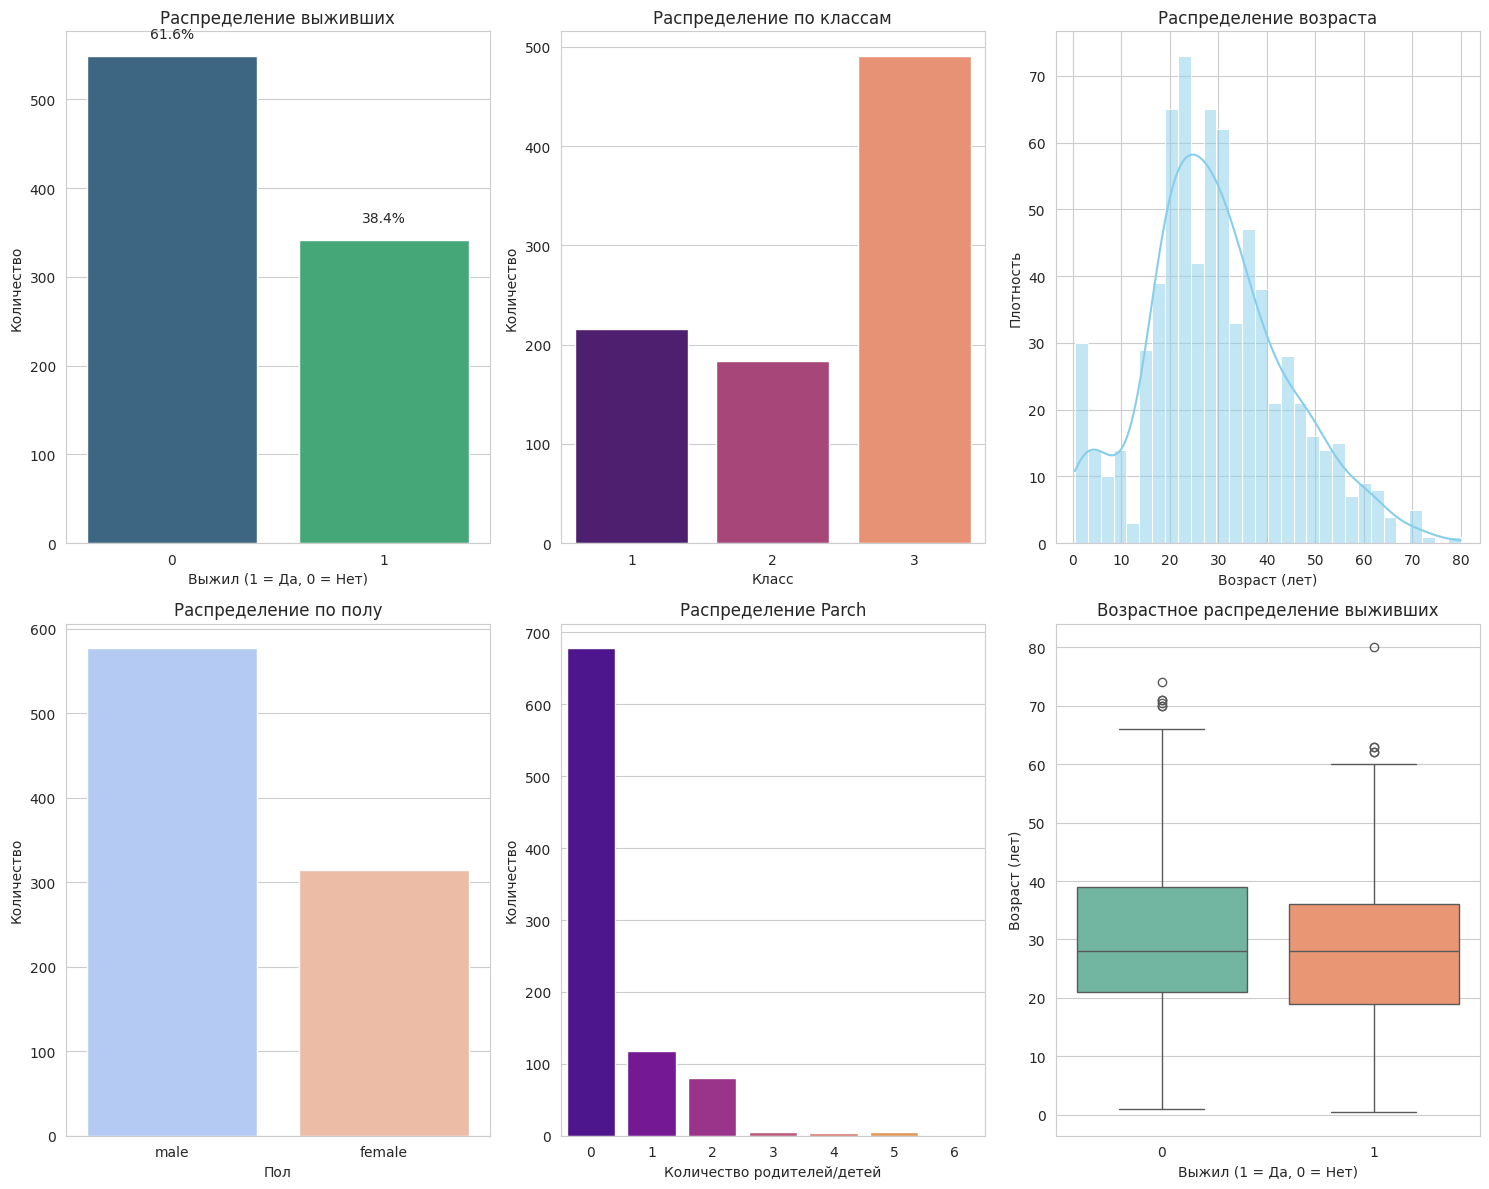

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(15, 12))

plt.subplot(2, 3, 1)
sns.countplot(x='Survived', data=df, palette='viridis')
plt.title('Распределение выживших')
plt.xlabel('Выжил (1 = Да, 0 = Нет)')
plt.ylabel('Количество')

total = len(df)
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(p.get_x() + p.get_width()/2, height + 20,
                  f'{height/total:.1%}', ha='center')

plt.subplot(2, 3, 2)
sns.countplot(x='Pclass', data=df, palette='magma')
plt.title('Распределение по классам')
plt.xlabel('Класс')
plt.ylabel('Количество')

plt.subplot(2, 3, 3)
sns.histplot(df['Age'].dropna(), kde=True, bins=30, color='skyblue')
plt.title('Распределение возраста')
plt.xlabel('Возраст (лет)')
plt.ylabel('Плотность')

plt.subplot(2, 3, 4)
sns.countplot(x='Sex', data=df, palette='coolwarm')
plt.title('Распределение по полу')
plt.xlabel('Пол')
plt.ylabel('Количество')

plt.subplot(2, 3, 5)
sns.countplot(x='Parch', data=df, palette='plasma')
plt.title('Распределение Parch')
plt.xlabel('Количество родителей/детей')
plt.ylabel('Количество')

plt.subplot(2, 3, 6)
sns.boxplot(x='Survived', y='Age', data=df, palette='Set2')
plt.title('Возрастное распределение выживших')
plt.xlabel('Выжил (1 = Да, 0 = Нет)')
plt.ylabel('Возраст (лет)')

plt.tight_layout()
plt.show()

Задание №3

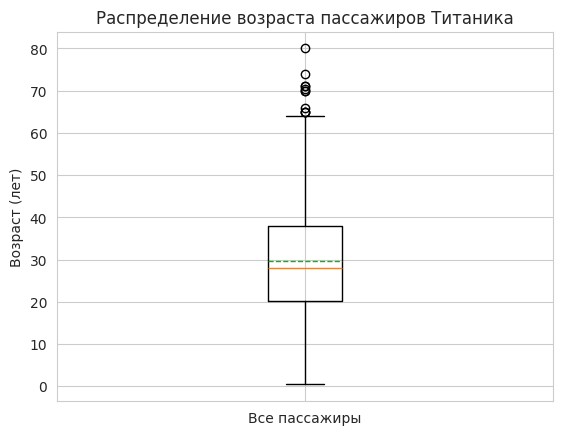

In [12]:
import numpy as np

df_3 = df['Age'].dropna()
size_array = df_3.shape
age_array=  np.empty((size_array))
#age_array = np.array([size_array])
index = 0
for element in df_3:
  age_array[index] = element
  index += 1
fig, ax = plt.subplots()
ax.boxplot(age_array, showmeans=True, meanline=True);
ax.set_title('Распределение возраста пассажиров Титаника')
ax.set_ylabel('Возраст (лет)')
ax.set_xticks([1], ['Все пассажиры'])

Задание №4 - Интерпитация графика.
На построенном графике видно, что около 50% пассажиров - люди от 20 до 38 лет.
Типичный пассажир - 28 лет, средний возраст - 30 лет

Медиана < Среднего → распределение сдвинуто вправо - это означает наличие группы пожилых пассажиров, которые "тянут" среднее вверх

Основная масса пассажиров - молодые взрослые (20-38 лет)
Значительное количество детей (нижний ус начинается с 0)
Небольшая группа пожилых людей (выбросы старше 60 лет)

Задание №5

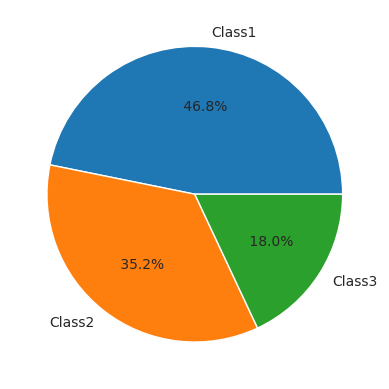

In [13]:
labels= ['Class1', 'Class2', 'Class3']
mean_survivals = df.groupby("Pclass")["Survived"].mean() * 100

fig, ax = plt.subplots()
ax.pie(mean_survivals, labels=labels, autopct= ' %1.1f%%');

Задание №6

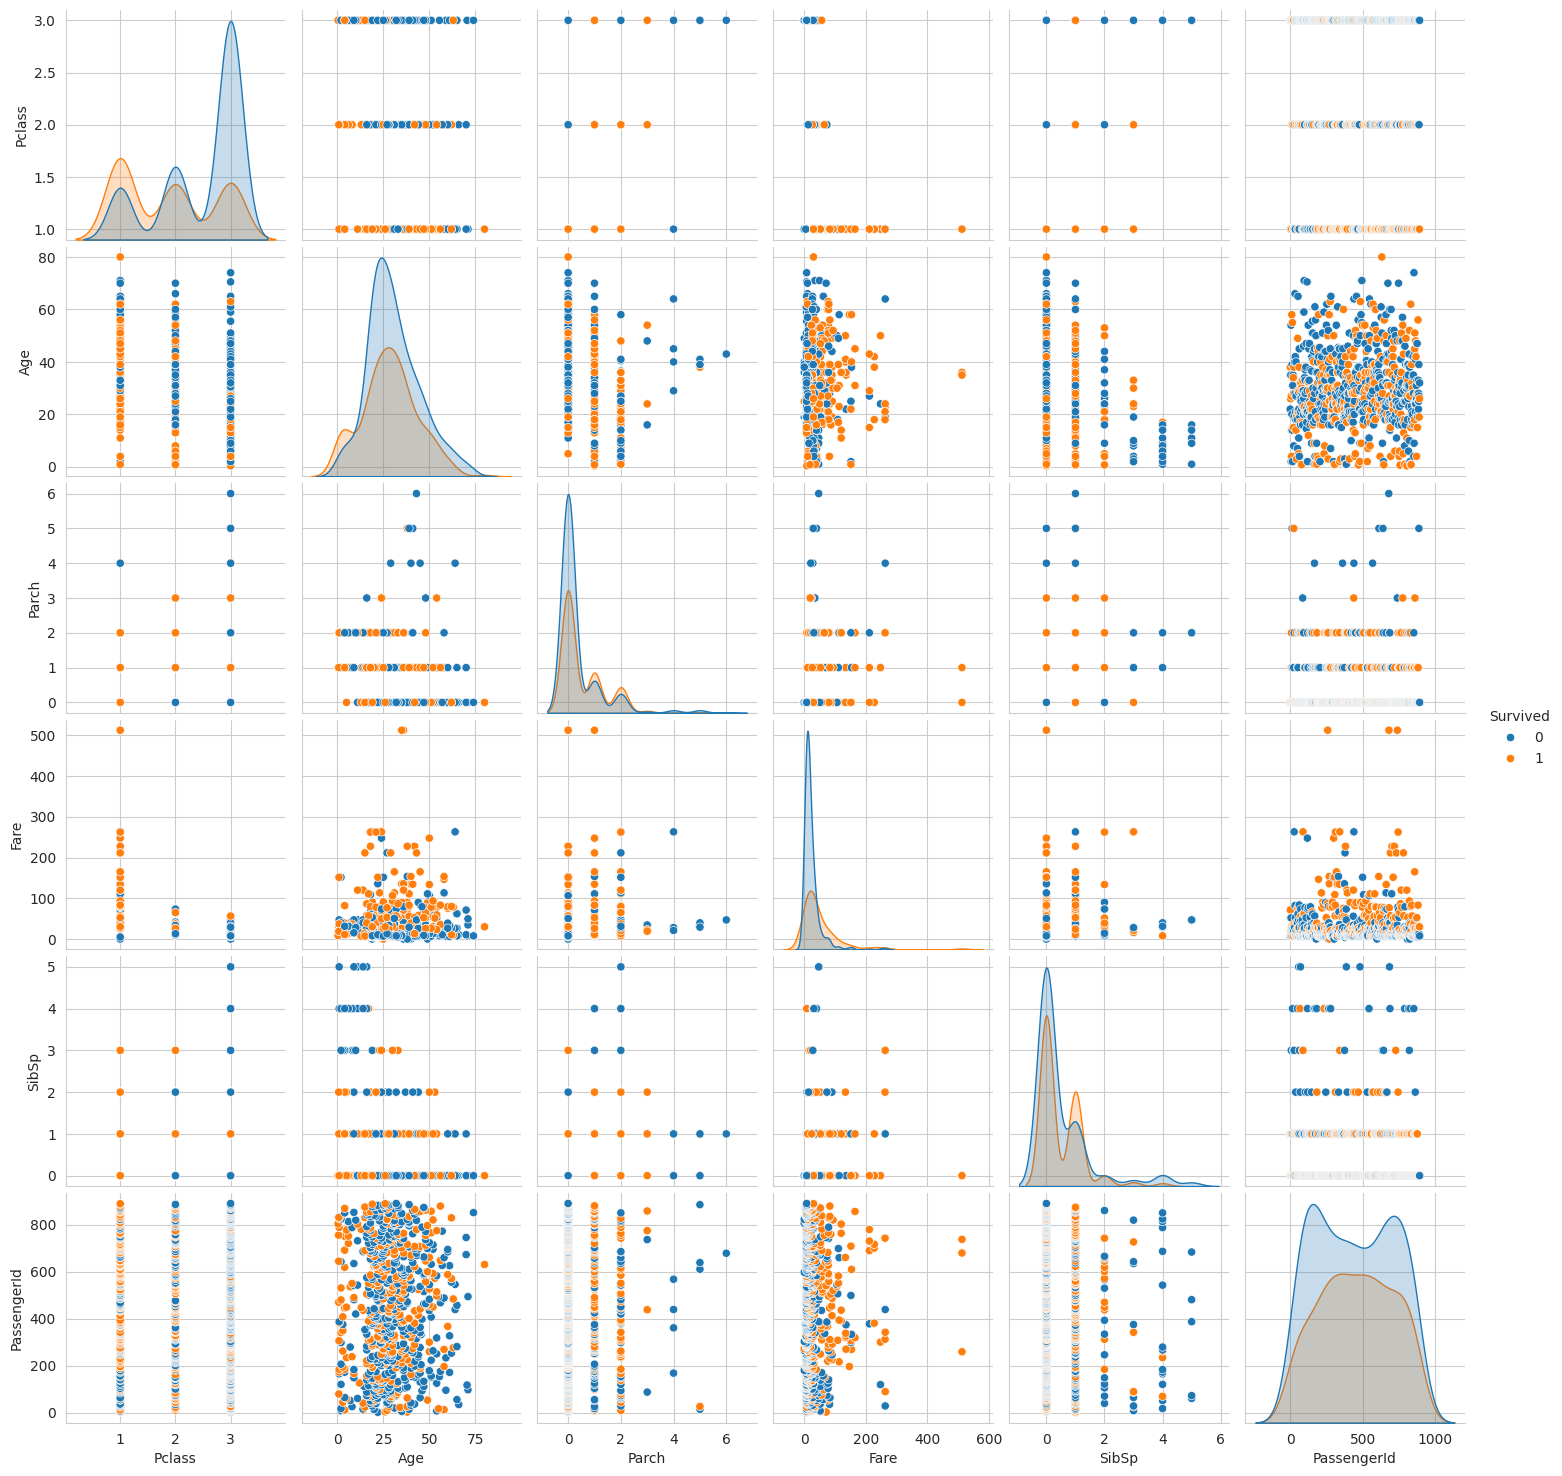

In [14]:
df_2 = df[['Survived', 'Pclass','Age', 'Parch', 'Fare', 'SibSp', 'PassengerId']].dropna()
sns.pairplot(df_2, hue="Survived");

Задание №7

In [15]:
import plotly.express as px
import pandas as pd

hierarchy_data = []

hierarchy_data.append({
    'label': 'Все пассажиры',
    'parent': '',
    'value': len(df),
    'level': 'Все'
})

for pclass in [1, 2, 3]:
    class_df = df[df['Pclass'] == pclass]
    class_total = len(class_df)
    hierarchy_data.append({
        'label': f'Класс {pclass}',
        'parent': 'Все пассажиры',
        'value': class_total,
        'level': 'Класс'
    })

    for sex in ['male', 'female']:
        sex_df = class_df[class_df['Sex'] == sex]
        sex_count = len(sex_df)
        sex_label = 'Мужчины' if sex == 'male' else 'Женщины'
        hierarchy_data.append({
            'label': f'{sex_label} (Кл. {pclass})',
            'parent': f'Класс {pclass}',
            'value': sex_count,
            'level': 'Пол'
        })

df_sunburst = pd.DataFrame(hierarchy_data)

fig = px.sunburst(
    df_sunburst,
    names='label',
    parents='parent',
    values='value',
    color='level',

    branchvalues='total',
    title='Распределение пассажиров Титаника по классам и полу',
)

fig.update_traces(
    hovertemplate='<b>%{label}</b><br>Количество: %{value}<br>Процент: %{percentParent:.1%}',
    textinfo='label+percent parent'
)

fig.update_layout(
    margin=dict(t=50, b=20, l=20, r=20),
    title_font_size=20
)

fig.show()